In [1]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 26.29,       # Jodhpur — drought-prone city
    "longitude": 73.02,
    "start_date": "2015-01-01",
    "end_date": "2023-12-31",
    "daily": ["precipitation_sum", "et0_fao_evapotranspiration"],
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data["daily"])
df["time"] = pd.to_datetime(df["time"])
df.columns = ["date", "rainfall_mm", "et0_mm"]

print(df.head(10))

        date  rainfall_mm  et0_mm
0 2015-01-01          0.9    2.64
1 2015-01-02          0.2    3.14
2 2015-01-03          0.0    2.98
3 2015-01-04          0.0    3.42
4 2015-01-05          0.0    3.22
5 2015-01-06          0.0    3.41
6 2015-01-07          0.0    3.25
7 2015-01-08          0.0    3.28
8 2015-01-09          0.0    3.82
9 2015-01-10          0.0    3.74


In [2]:
# Water deficit = how much more water evaporated than fell
df["water_deficit_mm"] = df["et0_mm"] - df["rainfall_mm"]

# Dry day = less than 1mm of rain
df["is_dry_day"] = df["rainfall_mm"] < 1.0

# Summary per year
df["year"] = df["date"].dt.year

yearly = df.groupby("year").agg(
    total_rainfall=("rainfall_mm", "sum"),
    total_et0=("et0_mm", "sum"),
    total_deficit=("water_deficit_mm", "sum"),
    dry_days=("is_dry_day", "sum")
).reset_index()

print(yearly)

   year  total_rainfall  total_et0  total_deficit  dry_days
0  2015           329.9    2098.45        1768.55       325
1  2016           417.4    2088.16        1670.76       324
2  2017           462.3    2064.18        1601.88       305
3  2018           172.3    2200.86        2028.56       340
4  2019           418.5    2006.10        1587.60       323
5  2020           489.7    1993.32        1503.62       313
6  2021           353.2    2068.32        1715.12       326
7  2022           576.7    2075.51        1498.81       309
8  2023           575.7    1931.46        1355.76       310


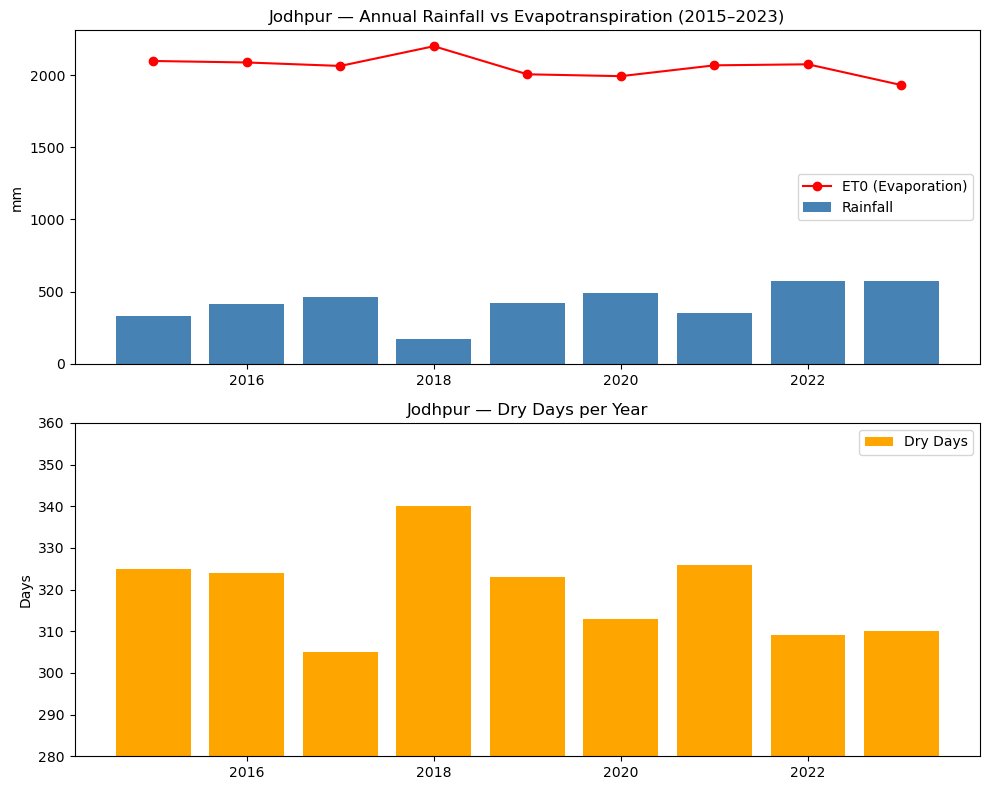

In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Chart 1 - Rainfall vs ET0
ax1.bar(yearly["year"], yearly["total_rainfall"], label="Rainfall", color="steelblue")
ax1.plot(yearly["year"], yearly["total_et0"], color="red", marker="o", label="ET0 (Evaporation)")
ax1.set_title("Jodhpur — Annual Rainfall vs Evapotranspiration (2015–2023)")
ax1.set_ylabel("mm")
ax1.legend()

# Chart 2 - Dry days
ax2.bar(yearly["year"], yearly["dry_days"], color="orange", label="Dry Days")
ax2.set_title("Jodhpur — Dry Days per Year")
ax2.set_ylabel("Days")
ax2.set_ylim(280, 360)
ax2.legend()

plt.tight_layout()
plt.savefig("../data/outputs/jodhpur_drought_overview.png", dpi=150)
plt.show()